# Q-learning analysis

This notebook studies tabular Q-learning on the simplified Pacman environment.

The experiments evaluate:

- the influence of the learning rate $\alpha$;
- the influence of the discount factor $\gamma$;
- convergence across several random seeds;
- success rate and path optimality.

Each configuration is trained for 1,000 episodes using five seeds. Evaluation is performed without exploration on 200 episodes with random valid starting positions.

In [1]:
from itertools import product
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from tqdm.auto import tqdm


project_root = Path.cwd()

if project_root.name == "notebooks":
    project_root = project_root.parent

if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))


from pacman_rl.agents.q_learning import QLearningAgent
from pacman_rl.environment import PacmanEnv
from pacman_rl.training import train_q_learning


results_directory = project_root / "results"
data_directory = results_directory / "data"
figures_directory = results_directory / "figures"

figures_directory.mkdir(
    parents=True,
    exist_ok=True,
)

plt.style.use("seaborn-v0_8-whitegrid")

c:\Users\zawad\Documents\MLDM\S9\python project\pacmanRL\Pacman-Reinforcement-learning-Project\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
alpha_results = pd.read_csv(
    data_directory / "q_learning_alpha_results.csv"
)

gamma_results = pd.read_csv(
    data_directory / "q_learning_gamma_results.csv"
)

print("Alpha experiments:", len(alpha_results))
print("Gamma experiments:", len(gamma_results))

display(alpha_results.head())
display(gamma_results.head())

Alpha experiments: 20
Gamma experiments: 20


,alpha,seed,training_episodes,last_100_mean_return,success_rate,ghost_rate,timeout_rate,mean_return,return_std,mean_steps,mean_optimal_steps,mean_efficiency_ratio,optimal_path_rate
0,0.01,0,1000,6.55,0.905,0.0,0.095,3.435,14.144107,6.520,3.385,0.905,0.905
1,0.01,1,1000,7.64,0.915,0.0,0.085,3.730,13.418908,6.335,3.530,0.915,0.915
2,0.01,2,1000,6.93,0.930,0.0,0.070,4.660,12.346433,5.570,3.260,0.930,0.930
3,0.01,3,1000,6.73,0.950,0.0,0.050,5.420,10.528704,5.030,3.380,0.950,0.950
4,0.01,4,1000,6.71,0.940,0.0,0.060,4.915,11.439308,5.425,3.445,0.940,0.940


,gamma,seed,training_episodes,last_100_mean_return,success_rate,ghost_rate,timeout_rate,mean_return,return_std,mean_steps,mean_optimal_steps,mean_efficiency_ratio,optimal_path_rate
0,0.5,0,1000,7.03,1.0,0.0,0.0,7.615,1.840319,3.385,3.385,1.0,1.0
1,0.5,1,1000,7.78,1.0,0.0,0.0,7.470,1.881250,3.530,3.530,1.0,1.0
2,0.5,2,1000,6.65,1.0,0.0,0.0,7.740,1.833685,3.260,3.260,1.0,1.0
3,0.5,3,1000,7.36,1.0,0.0,0.0,7.620,1.722092,3.380,3.380,1.0,1.0
4,0.5,4,1000,6.97,1.0,0.0,0.0,7.555,1.702050,3.445,3.445,1.0,1.0


In [3]:
alpha_summary = alpha_results.groupby("alpha").agg(
    success_rate_mean=("success_rate", "mean"),
    success_rate_std=("success_rate", "std"),
    timeout_rate_mean=("timeout_rate", "mean"),
    training_return_mean=(
        "last_100_mean_return",
        "mean",
    ),
    training_return_std=(
        "last_100_mean_return",
        "std",
    ),
    efficiency_mean=(
        "mean_efficiency_ratio",
        "mean",
    ),
    optimal_path_rate_mean=(
        "optimal_path_rate",
        "mean",
    ),
)

gamma_summary = gamma_results.groupby("gamma").agg(
    success_rate_mean=("success_rate", "mean"),
    success_rate_std=("success_rate", "std"),
    training_return_mean=(
        "last_100_mean_return",
        "mean",
    ),
    training_return_std=(
        "last_100_mean_return",
        "std",
    ),
    efficiency_mean=(
        "mean_efficiency_ratio",
        "mean",
    ),
    optimal_path_rate_mean=(
        "optimal_path_rate",
        "mean",
    ),
)

print("Learning-rate comparison")
display(alpha_summary.round(3))

print("Discount-factor comparison")
display(gamma_summary.round(3))

Learning-rate comparison


,success_rate_mean,success_rate_std,timeout_rate_mean,training_return_mean,training_return_std,efficiency_mean,optimal_path_rate_mean
alpha,,,,,,,
0.01,0.928,0.018,0.072,6.912,0.429,0.928,0.928
0.10,1.000,0.000,0.000,7.280,0.357,1.000,1.000
0.50,1.000,0.000,0.000,7.288,0.432,1.000,1.000
0.90,1.000,0.000,0.000,7.214,0.331,1.000,1.000


Discount-factor comparison


,success_rate_mean,success_rate_std,training_return_mean,training_return_std,efficiency_mean,optimal_path_rate_mean
gamma,,,,,,
0.50,1.0,0.0,7.158,0.429,1.0,1.0
0.70,1.0,0.0,7.210,0.414,1.0,1.0
0.90,1.0,0.0,7.302,0.298,1.0,1.0
0.99,1.0,0.0,7.280,0.357,1.0,1.0


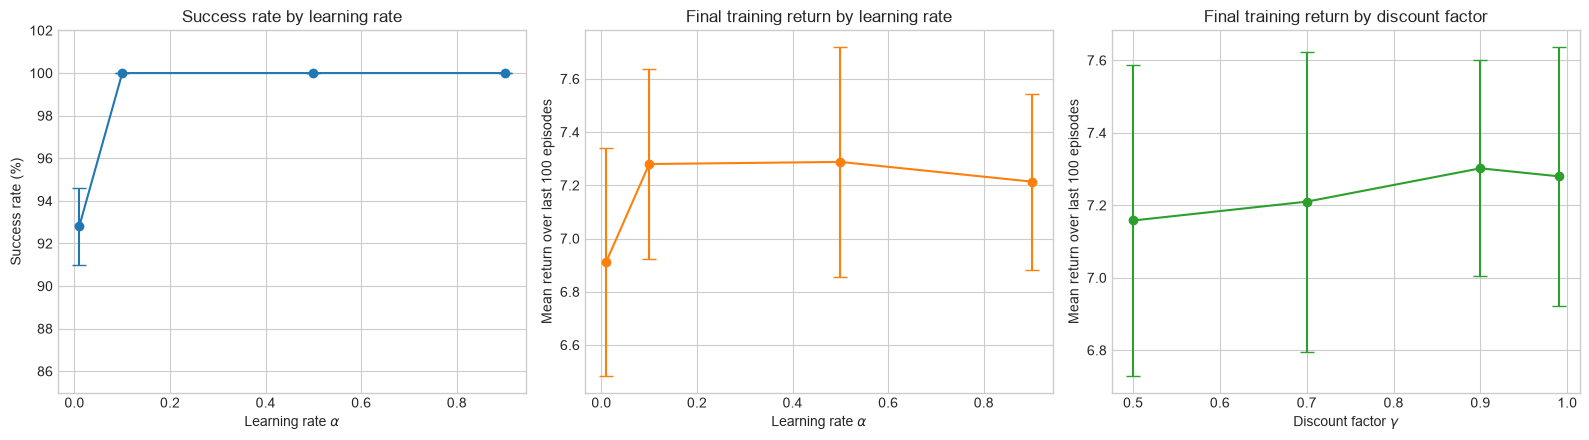

Figure saved to c:\Users\zawad\Documents\MLDM\S9\python project\pacmanRL\Pacman-Reinforcement-learning-Project\results\figures\q_learning_parameter_summary.png


In [4]:
fig, axes = plt.subplots(
    1,
    3,
    figsize=(16, 4.5),
)

alpha_x = alpha_summary.index.to_numpy()
gamma_x = gamma_summary.index.to_numpy()

axes[0].errorbar(
    alpha_x,
    100 * alpha_summary["success_rate_mean"],
    yerr=100 * alpha_summary["success_rate_std"].fillna(0),
    marker="o",
    capsize=5,
)

axes[0].set_title("Success rate by learning rate")
axes[0].set_xlabel(r"Learning rate $\alpha$")
axes[0].set_ylabel("Success rate (%)")
axes[0].set_ylim(85, 102)

axes[1].errorbar(
    alpha_x,
    alpha_summary["training_return_mean"],
    yerr=alpha_summary["training_return_std"].fillna(0),
    marker="o",
    capsize=5,
    color="tab:orange",
)

axes[1].set_title("Final training return by learning rate")
axes[1].set_xlabel(r"Learning rate $\alpha$")
axes[1].set_ylabel("Mean return over last 100 episodes")

axes[2].errorbar(
    gamma_x,
    gamma_summary["training_return_mean"],
    yerr=gamma_summary["training_return_std"].fillna(0),
    marker="o",
    capsize=5,
    color="tab:green",
)

axes[2].set_title("Final training return by discount factor")
axes[2].set_xlabel(r"Discount factor $\gamma$")
axes[2].set_ylabel("Mean return over last 100 episodes")

fig.tight_layout()

summary_figure_path = (
    figures_directory
    / "q_learning_parameter_summary.png"
)

fig.savefig(
    summary_figure_path,
    dpi=160,
    bbox_inches="tight",
)

plt.show()

print(f"Figure saved to {summary_figure_path}")

In [5]:
def collect_learning_curves(
    parameter_name,
    parameter_values,
    seeds,
    episodes=1000,
    rolling_window=50,
):
    records = []

    combinations = list(
        product(parameter_values, seeds)
    )

    for parameter_value, seed in tqdm(
        combinations,
        desc=f"Running {parameter_name} experiments",
    ):
        alpha = (
            parameter_value
            if parameter_name == "alpha"
            else 0.1
        )

        gamma = (
            parameter_value
            if parameter_name == "gamma"
            else 0.99
        )

        env = PacmanEnv(
            random_start=True,
            seed=seed,
        )

        agent = QLearningAgent(
            n_states=env.rows * env.cols,
            n_actions=env.n_actions,
            alpha=alpha,
            gamma=gamma,
            epsilon=1.0,
            epsilon_min=0.05,
            epsilon_decay=0.995,
            seed=seed,
        )

        history = train_q_learning(
            env=env,
            agent=agent,
            episodes=episodes,
        )

        smoothed_returns = (
            pd.Series(history.episode_returns)
            .rolling(
                window=rolling_window,
                min_periods=1,
            )
            .mean()
        )

        for episode, smoothed_return in enumerate(
            smoothed_returns,
            start=1,
        ):
            records.append(
                {
                    parameter_name: parameter_value,
                    "seed": seed,
                    "episode": episode,
                    "smoothed_return": smoothed_return,
                }
            )

    return pd.DataFrame(records)

In [6]:
seeds = [0, 1, 2, 3, 4]

alpha_curves = collect_learning_curves(
    parameter_name="alpha",
    parameter_values=[0.01, 0.1, 0.5, 0.9],
    seeds=seeds,
)

gamma_curves = collect_learning_curves(
    parameter_name="gamma",
    parameter_values=[0.5, 0.7, 0.9, 0.99],
    seeds=seeds,
)

print("Alpha curve rows:", len(alpha_curves))
print("Gamma curve rows:", len(gamma_curves))

Running gamma experiments: 100%|██████████| 20/20 [00:02<00:00,  7.71it/s]


Alpha curve rows: 20000
Gamma curve rows: 20000


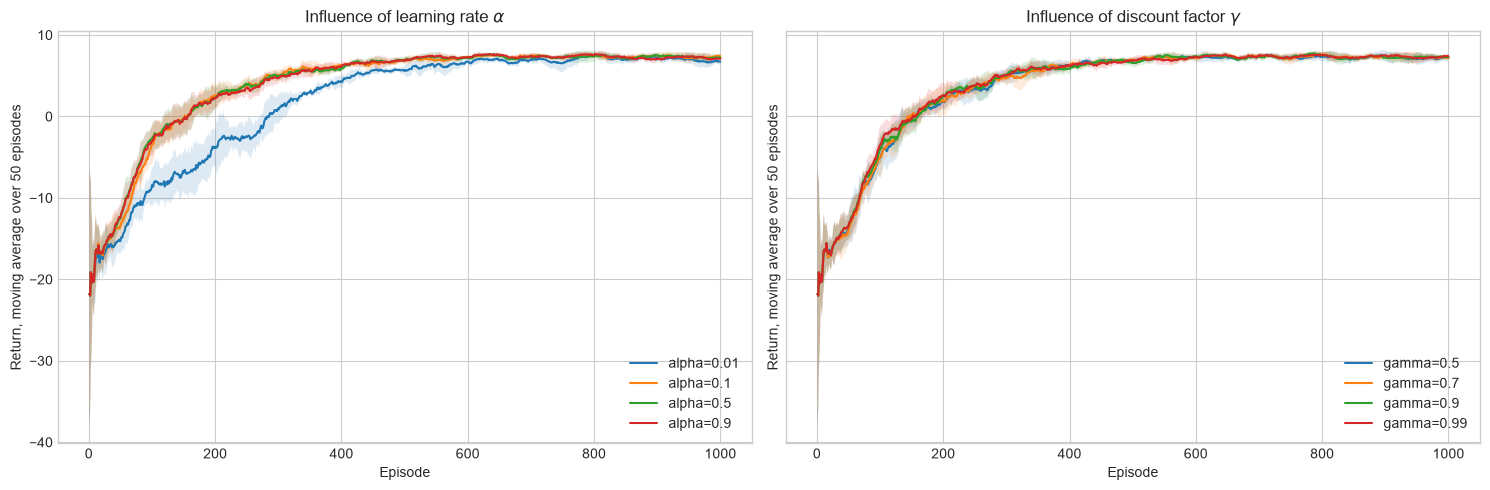

Figure saved to c:\Users\zawad\Documents\MLDM\S9\python project\pacmanRL\Pacman-Reinforcement-learning-Project\results\figures\q_learning_parameter_curves.png


In [7]:
def plot_learning_curves(
    data,
    parameter_name,
    axis,
):
    summary = (
        data.groupby(
            [parameter_name, "episode"]
        )["smoothed_return"]
        .agg(["mean", "std"])
        .reset_index()
    )

    for parameter_value in sorted(
        data[parameter_name].unique()
    ):
        parameter_data = summary[
            summary[parameter_name] == parameter_value
        ]

        episodes = parameter_data["episode"].to_numpy()
        means = parameter_data["mean"].to_numpy()
        standard_deviations = (
            parameter_data["std"]
            .fillna(0)
            .to_numpy()
        )

        axis.plot(
            episodes,
            means,
            label=f"{parameter_name}={parameter_value}",
        )

        axis.fill_between(
            episodes,
            means - standard_deviations,
            means + standard_deviations,
            alpha=0.15,
        )

    axis.set_xlabel("Episode")
    axis.set_ylabel("Return, moving average over 50 episodes")
    axis.legend()


fig, axes = plt.subplots(
    1,
    2,
    figsize=(15, 5),
    sharey=True,
)

plot_learning_curves(
    alpha_curves,
    "alpha",
    axes[0],
)

axes[0].set_title(
    r"Influence of learning rate $\alpha$"
)

plot_learning_curves(
    gamma_curves,
    "gamma",
    axes[1],
)

axes[1].set_title(
    r"Influence of discount factor $\gamma$"
)

fig.tight_layout()

curves_figure_path = (
    figures_directory
    / "q_learning_parameter_curves.png"
)

fig.savefig(
    curves_figure_path,
    dpi=160,
    bbox_inches="tight",
)

plt.show()

print(f"Figure saved to {curves_figure_path}")

## Interpretation

### Learning rate

The learning rate has a visible influence on convergence. With $\alpha=0.01$, updates of the Q-table are small and learning remains incomplete after 1,000 episodes. The mean success rate is 92.8%, with 7.2% timeouts.

For $\alpha \in \{0.1, 0.5, 0.9\}$, all five seeds reach a 100% success rate and a 100% optimal-path rate. The environment is deterministic, so large learning rates do not destabilize the final policy in this experiment. We retain $\alpha=0.1$ as a conservative compromise.

### Discount factor

All tested values of $\gamma$ between 0.5 and 0.99 produce an optimal final policy after 1,000 episodes. The reference grid is small, and the PAC-DOT reward can be propagated through the state space even with a relatively low discount factor.

No significant influence of $\gamma$ is observed on final performance. We retain $\gamma=0.99$ because future rewards will be more important on larger grids.

## Conclusion

Tabular Q-learning successfully solves the fixed Pacman environment. With $\alpha=0.1$ and $\gamma=0.99$, the learned policy reaches the PAC-DOT from all evaluated starting positions, avoids the ghost, and follows a shortest safe path.

The next experiments will evaluate how the method scales when the size of the grid increases.

# Influence of grid size and layout

The previous experiments selected fixed hyperparameters:

- learning rate: $\alpha = 0.1$;
- discount factor: $\gamma = 0.99$.

We now study how Q-learning behaves when the state space and maze configuration change.

For each grid size, the experiment uses:

- 10 different layouts;
- 5 training seeds per layout;
- 3000 training episodes;
- 200 greedy evaluation episodes.

This gives:

$$
4 \text{ sizes} \times 10 \text{ layouts} \times 5 \text{ seeds}
= 200 \text{ training runs}.
$$

The hyperparameters remain fixed so that the effect of grid size and layout is not mixed with a new parameter optimization.

In [8]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


possible_paths = [
    Path("results/data/q_learning_scaling_results.csv"),
    Path("../results/data/q_learning_scaling_results.csv"),
]

scaling_path = next(
    (
        path
        for path in possible_paths
        if path.exists()
    ),
    None,
)

if scaling_path is None:
    raise FileNotFoundError(
        "Could not find q_learning_scaling_results.csv"
    )

scaling_results = pd.read_csv(scaling_path)

grid_order = [
    "4x5",
    "6x6",
    "8x8",
    "10x10",
]

scaling_results["grid"] = pd.Categorical(
    scaling_results["grid"],
    categories=grid_order,
    ordered=True,
)

assert len(scaling_results) == 200

assert (
    scaling_results
    .groupby("grid", observed=True)
    .size()
    .eq(50)
    .all()
)

assert (
    scaling_results
    .groupby("grid", observed=True)["layout"]
    .nunique()
    .eq(10)
    .all()
)

assert (
    scaling_results
    .groupby(
        ["grid", "layout"],
        observed=True,
    )["seed"]
    .nunique()
    .eq(5)
    .all()
)

print("Number of runs:", len(scaling_results))
print("Layouts per size: 10")
print("Seeds per layout: 5")

scaling_results.head()

Number of runs: 200
Layouts per size: 10
Seeds per layout: 5


,grid,layout,rows,cols,n_states,seed,training_episodes,training_time_seconds,episodes_per_second,success_rate,ghost_rate,timeout_rate,mean_return,return_std,mean_steps,mean_optimal_steps,mean_efficiency_ratio,optimal_path_rate
0,4x5,1,4,5,20,0,3000,0.434064,6911.431161,1.0,0.0,0.0,7.545,1.816033,3.455,3.455,1.0,1.0
1,4x5,1,4,5,20,1,3000,0.382422,7844.726711,1.0,0.0,0.0,7.405,1.827833,3.595,3.595,1.0,1.0
2,4x5,1,4,5,20,2,3000,0.323522,9272.936838,1.0,0.0,0.0,7.720,1.749743,3.280,3.280,1.0,1.0
3,4x5,1,4,5,20,3,3000,0.313230,9577.629723,1.0,0.0,0.0,7.595,1.783529,3.405,3.405,1.0,1.0
4,4x5,1,4,5,20,4,3000,0.312223,9608.504680,1.0,0.0,0.0,7.570,1.834421,3.430,3.430,1.0,1.0


In [9]:
layout_results = (
    scaling_results
    .groupby(
        ["grid", "layout"],
        observed=True,
        as_index=False,
    )
    .agg(
        training_time=(
            "training_time_seconds",
            "mean",
        ),
        episodes_per_second=(
            "episodes_per_second",
            "mean",
        ),
        success_rate=(
            "success_rate",
            "mean",
        ),
        ghost_rate=(
            "ghost_rate",
            "mean",
        ),
        timeout_rate=(
            "timeout_rate",
            "mean",
        ),
        mean_return=(
            "mean_return",
            "mean",
        ),
        mean_steps=(
            "mean_steps",
            "mean",
        ),
        mean_optimal_steps=(
            "mean_optimal_steps",
            "mean",
        ),
        mean_efficiency_ratio=(
            "mean_efficiency_ratio",
            "mean",
        ),
        optimal_path_rate=(
            "optimal_path_rate",
            "mean",
        ),
    )
)

assert len(layout_results) == 40

layout_results.head()

,grid,layout,training_time,episodes_per_second,success_rate,ghost_rate,timeout_rate,mean_return,mean_steps,mean_optimal_steps,mean_efficiency_ratio,optimal_path_rate
0,4x5,1,0.353092,8643.045822,1.0,0.0,0.0,7.567,3.433,3.433,1.0,1.0
1,4x5,2,0.224363,13396.578388,1.0,0.0,0.0,8.552,2.448,2.448,1.0,1.0
2,4x5,3,0.221845,13551.519006,1.0,0.0,0.0,8.729,2.271,2.271,1.0,1.0
3,4x5,4,0.236787,12691.078230,1.0,0.0,0.0,8.477,2.523,2.523,1.0,1.0
4,4x5,5,0.200819,14940.710162,1.0,0.0,0.0,8.724,2.276,2.276,1.0,1.0


In [10]:
size_summary = (
    layout_results
    .groupby(
        "grid",
        observed=True,
        as_index=False,
    )
    .agg(
        training_time_mean=(
            "training_time",
            "mean",
        ),
        training_time_std=(
            "training_time",
            "std",
        ),
        episodes_per_second_mean=(
            "episodes_per_second",
            "mean",
        ),
        episodes_per_second_std=(
            "episodes_per_second",
            "std",
        ),
        success_rate_mean=(
            "success_rate",
            "mean",
        ),
        mean_return=(
            "mean_return",
            "mean",
        ),
        mean_return_std=(
            "mean_return",
            "std",
        ),
        mean_steps=(
            "mean_steps",
            "mean",
        ),
        mean_steps_std=(
            "mean_steps",
            "std",
        ),
        mean_optimal_steps=(
            "mean_optimal_steps",
            "mean",
        ),
        efficiency_mean=(
            "mean_efficiency_ratio",
            "mean",
        ),
        optimal_path_rate_mean=(
            "optimal_path_rate",
            "mean",
        ),
    )
)

display_summary = size_summary.copy()

for column in [
    "success_rate_mean",
    "efficiency_mean",
    "optimal_path_rate_mean",
]:
    display_summary[column] *= 100

display_summary = display_summary.rename(
    columns={
        "grid": "Grid",
        "training_time_mean": "Training time (s)",
        "training_time_std": "Time std",
        "episodes_per_second_mean": "Episodes/s",
        "success_rate_mean": "Success (%)",
        "mean_return": "Mean return",
        "mean_steps": "Mean steps",
        "mean_optimal_steps": "Optimal steps",
        "efficiency_mean": "Efficiency (%)",
        "optimal_path_rate_mean": "Optimal paths (%)",
    }
)

display(
    display_summary[
        [
            "Grid",
            "Training time (s)",
            "Time std",
            "Episodes/s",
            "Success (%)",
            "Mean return",
            "Mean steps",
            "Optimal steps",
            "Efficiency (%)",
            "Optimal paths (%)",
        ]
    ].round(3)
)

,Grid,Training time (s),Time std,Episodes/s,Success (%),Mean return,Mean steps,Optimal steps,Efficiency (%),Optimal paths (%)
0,4x5,0.275,0.065,11473.641,100.0,8.086,2.914,2.914,100.000,100.00
1,6x6,0.468,0.080,6600.022,100.0,6.397,4.603,4.595,99.894,99.63
2,8x8,0.645,0.157,4894.995,100.0,4.476,6.524,6.520,99.943,99.79
3,10x10,0.772,0.132,3993.236,100.0,4.033,6.967,6.965,99.979,99.90


In [12]:
layout_variability = (
    layout_results
    .groupby(
        "grid",
        observed=True,
    )
    .agg(
        shortest_layout=(
            "mean_optimal_steps",
            "min",
        ),
        longest_layout=(
            "mean_optimal_steps",
            "max",
        ),
        lowest_return=(
            "mean_return",
            "min",
        ),
        highest_return=(
            "mean_return",
            "max",
        ),
        lowest_optimal_path_rate=(
            "optimal_path_rate",
            "min",
        ),
    )
)

layout_variability[
    "lowest_optimal_path_rate"
] *= 100

layout_variability = layout_variability.rename(
    columns={
        "shortest_layout": "Shortest mean path",
        "longest_layout": "Longest mean path",
        "lowest_return": "Lowest return",
        "highest_return": "Highest return",
        "lowest_optimal_path_rate": (
            "Lowest optimal-path rate (%)"
        ),
    }
)

display(layout_variability.round(3))

,Shortest mean path,Longest mean path,Lowest return,Highest return,Lowest optimal-path rate (%)
grid,,,,,
4x5,2.271,4.174,6.826,8.729,100.0
6x6,3.589,6.170,4.830,7.411,96.3
8x8,4.710,9.949,1.051,6.290,98.4
10x10,5.243,8.670,2.330,5.757,99.0


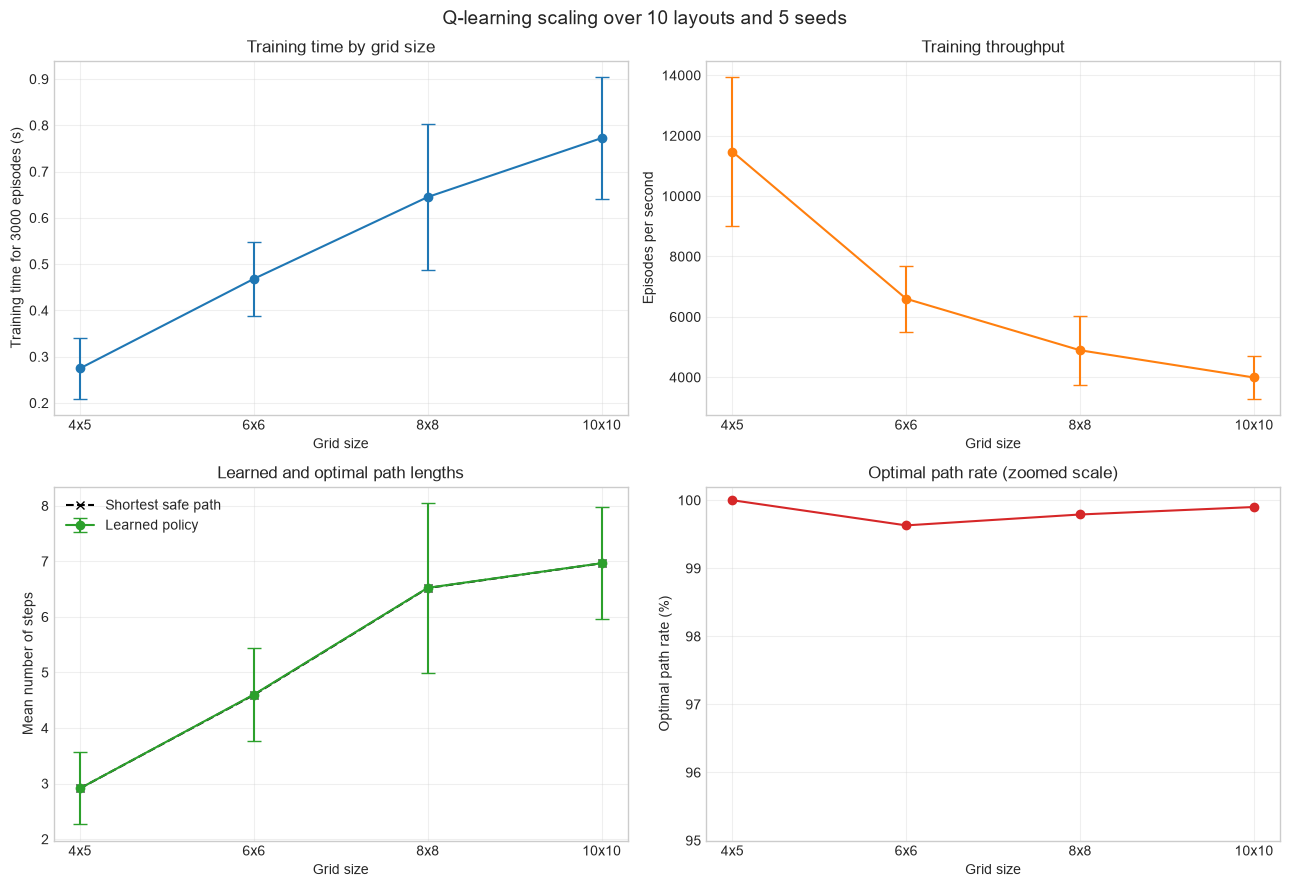

Figure saved to ..\results\figures\q_learning_scaling_summary.png


In [13]:
x_positions = np.arange(
    len(size_summary)
)

grid_labels = (
    size_summary["grid"]
    .astype(str)
    .tolist()
)

figure, axes = plt.subplots(
    2,
    2,
    figsize=(13, 9),
)

axes[0, 0].errorbar(
    x_positions,
    size_summary["training_time_mean"],
    yerr=size_summary["training_time_std"],
    marker="o",
    capsize=5,
)

axes[0, 0].set_title(
    "Training time by grid size"
)
axes[0, 0].set_ylabel(
    "Training time for 3000 episodes (s)"
)

axes[0, 1].errorbar(
    x_positions,
    size_summary["episodes_per_second_mean"],
    yerr=size_summary["episodes_per_second_std"],
    marker="o",
    capsize=5,
    color="tab:orange",
)

axes[0, 1].set_title(
    "Training throughput"
)
axes[0, 1].set_ylabel(
    "Episodes per second"
)

axes[1, 0].errorbar(
    x_positions,
    size_summary["mean_steps"],
    yerr=size_summary["mean_steps_std"],
    marker="o",
    capsize=5,
    label="Learned policy",
    color="tab:green",
)

axes[1, 0].plot(
    x_positions,
    size_summary["mean_optimal_steps"],
    marker="x",
    linestyle="--",
    label="Shortest safe path",
    color="black",
)

axes[1, 0].set_title(
    "Learned and optimal path lengths"
)
axes[1, 0].set_ylabel(
    "Mean number of steps"
)
axes[1, 0].legend()

axes[1, 1].plot(
    x_positions,
    (
        size_summary[
            "optimal_path_rate_mean"
        ]
        * 100
    ),
    marker="o",
    color="tab:red",
)

axes[1, 1].set_title(
    "Optimal path rate (zoomed scale)"
)
axes[1, 1].set_ylabel(
    "Optimal path rate (%)"
)
axes[1, 1].set_ylim(95, 100.2)

for axis in axes.flat:
    axis.set_xticks(
        x_positions,
        grid_labels,
    )
    axis.set_xlabel("Grid size")
    axis.grid(alpha=0.3)

figure.suptitle(
    "Q-learning scaling over 10 layouts and 5 seeds",
    fontsize=14,
)

figure.tight_layout()

figure_directory = (
    scaling_path.parent.parent
    / "figures"
)

figure_directory.mkdir(
    parents=True,
    exist_ok=True,
)

scaling_figure_path = (
    figure_directory
    / "q_learning_scaling_summary.png"
)

figure.savefig(
    scaling_figure_path,
    dpi=150,
    bbox_inches="tight",
)

plt.show()

print(
    f"Figure saved to {scaling_figure_path}"
)

## Interpretation

The final greedy policy reaches the PAC-DOT in every evaluation episode for all four grid sizes. No ghost collision or timeout is observed among the 200 training runs.

The mean training time increases from approximately 0.275 seconds on the 4×5 grids to 0.773 seconds on the 10×10 grids. At the same time, training throughput decreases from approximately 11,474 to 3,993 episodes per second. Larger grids therefore require more computation because the Q-table contains more states and the episodes generally contain more transitions.

The average number of steps increases from approximately 2.91 on the 4×5 grids to 6.97 on the 10×10 grids. The evolution is not perfectly linear because the path length also depends on wall placement and the position of the PAC-DOT. The use of 10 layouts per size makes this variability visible.

The mean return decreases as paths become longer. For a successful episode of length $L$, the undiscounted return is:

$$
G = 10 - (L - 1) = 11 - L.
$$

Consequently, a lower return on a larger grid does not necessarily indicate a worse policy. It can simply result from a longer optimal path.

Path efficiency remains above 99.8%, and more than 99.6% of evaluated trajectories follow a shortest safe path. The few suboptimal trajectories are therefore marginal and do not prevent the agent from reaching its objective.